# 0. Biblioteki

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.callbacks import EarlyStopping

# 1. Sprawdzenie danych i wyniki dla bazowego zbioru

### 1.1. Sprawdzenie danych

In [39]:
df = pd.read_csv('SeoulBikeData.csv')

In [40]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [41]:
df.describe()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [42]:
df.isnull().sum()

Date                        0
Rented Bike Count           0
Hour                        0
Temperature(C)              0
Humidity(%)                 0
Wind speed (m/s)            0
Visibility (10m)            0
Dew point temperature(C)    0
Solar Radiation (MJ/m2)     0
Rainfall(mm)                0
Snowfall (cm)               0
Seasons                     0
Holiday                     0
Functioning Day             0
dtype: int64

In [43]:
df.dtypes

Date                         object
Rented Bike Count             int64
Hour                          int64
Temperature(C)              float64
Humidity(%)                   int64
Wind speed (m/s)            float64
Visibility (10m)              int64
Dew point temperature(C)    float64
Solar Radiation (MJ/m2)     float64
Rainfall(mm)                float64
Snowfall (cm)               float64
Seasons                      object
Holiday                      object
Functioning Day              object
dtype: object

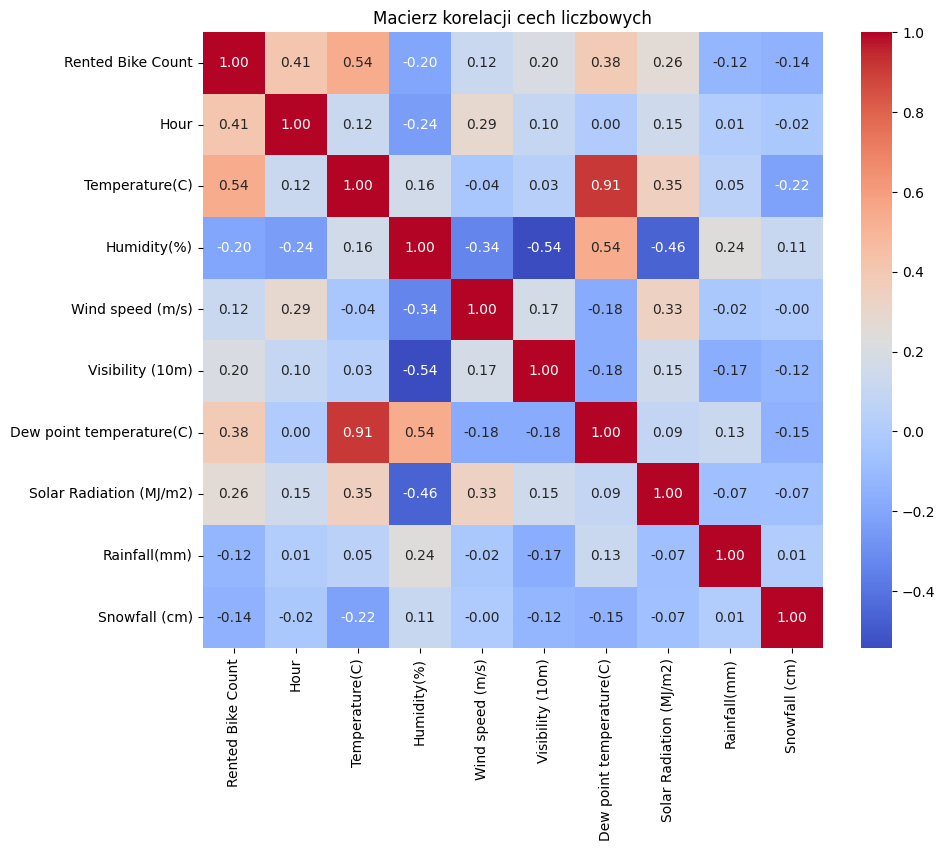

Rented Bike Count           1.000000
Temperature(C)              0.538558
Hour                        0.410257
Dew point temperature(C)    0.379788
Solar Radiation (MJ/m2)     0.261837
Visibility (10m)            0.199280
Wind speed (m/s)            0.121108
Rainfall(mm)               -0.123074
Snowfall (cm)              -0.141804
Humidity(%)                -0.199780
Name: Rented Bike Count, dtype: float64

In [44]:
numeric_columns = df.select_dtypes(include=['number'])
correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Macierz korelacji cech liczbowych")
plt.show()

correlation_with_target = correlation_matrix['Rented Bike Count'].sort_values(ascending=False)
correlation_with_target

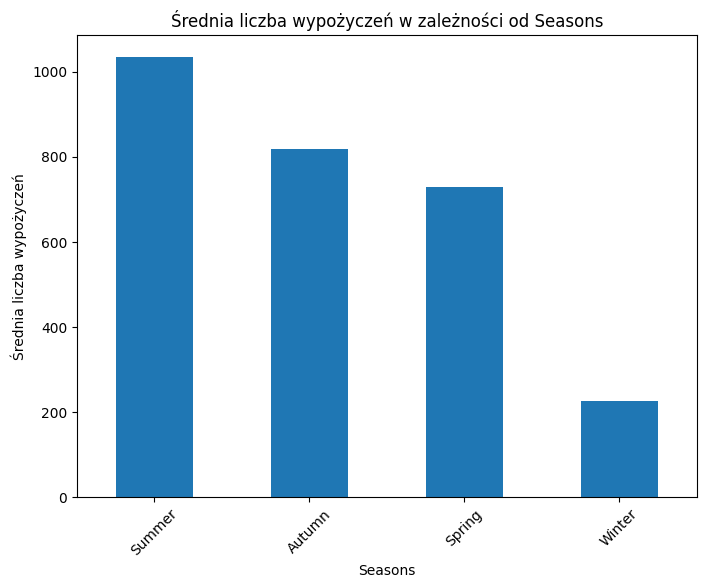

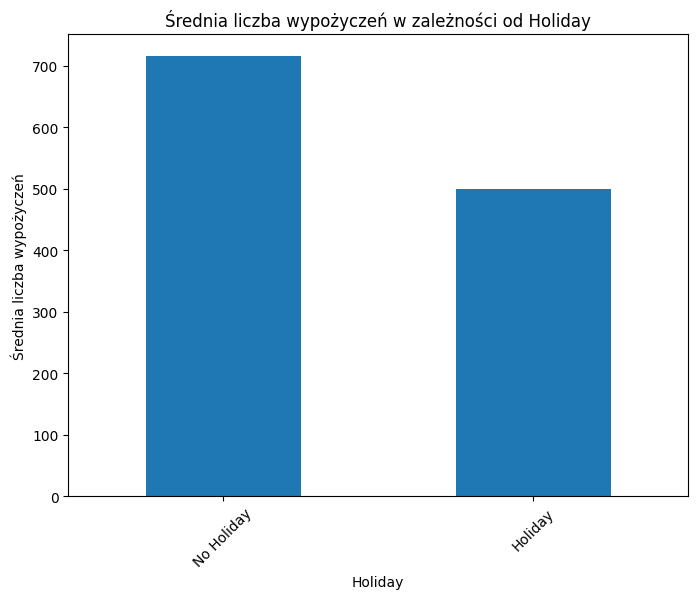

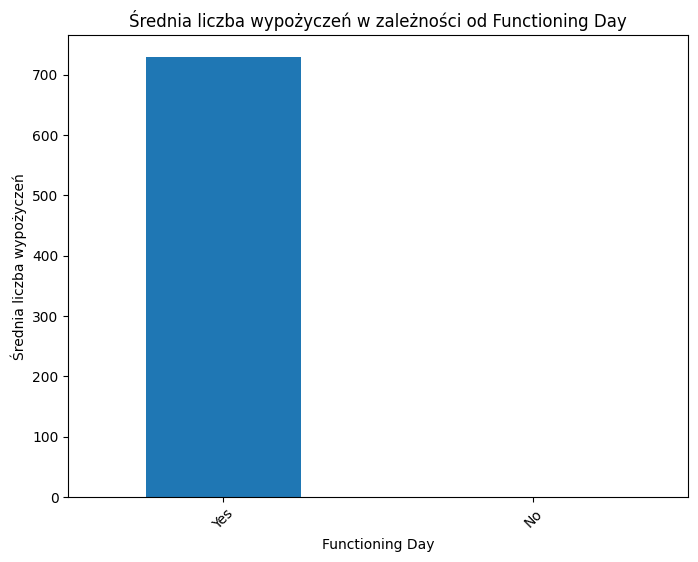

{'Seasons': Seasons
 Summer    1034.073370
 Autumn     819.597985
 Spring     730.031250
 Winter     225.541204
 Name: Rented Bike Count, dtype: float64,
 'Holiday': Holiday
 No Holiday    715.228026
 Holiday       499.756944
 Name: Rented Bike Count, dtype: float64,
 'Functioning Day': Functioning Day
 Yes    729.156999
 No       0.000000
 Name: Rented Bike Count, dtype: float64}

In [45]:
categorical_columns = ['Seasons', 'Holiday', 'Functioning Day']

categorical_analysis = {
    col: df.groupby(col)['Rented Bike Count'].mean().sort_values(ascending=False)
    for col in categorical_columns
}

for col, values in categorical_analysis.items():
    plt.figure(figsize=(8, 6))
    values.plot(kind='bar', title=f'Średnia liczba wypożyczeń w zależności od {col}', ylabel='Średnia liczba wypożyczeń')
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.show()

categorical_analysis

### 1.2. Wyniki dla nie przygotowanych danych

In [46]:
numerical_columns = df.select_dtypes(include=['number']).drop(columns=['Rented Bike Count'])

encoder = OneHotEncoder(sparse_output=False, drop=None)

encoded_features = encoder.fit_transform(df[categorical_columns])
encoded_feature_names = encoder.get_feature_names_out(categorical_columns)

encoded_data = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df.index)

processed_data_full = pd.concat([numerical_columns, encoded_data], axis=1)

processed_data_full['Rented Bike Count'] = df['Rented Bike Count']

X_full = processed_data_full.drop(columns=['Rented Bike Count'])
y_full = processed_data_full['Rented Bike Count']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

encoded_data.head()


,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [47]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_full, y_train_full)

rf_predictions = rf_model.predict(X_test_full)

rf_mse = mean_squared_error(y_test_full, rf_predictions)
rf_r2 = r2_score(y_test_full, rf_predictions)

In [48]:
lr_model = LinearRegression()
lr_model.fit(X_train_full, y_train_full)

lr_predictions = lr_model.predict(X_test_full)

lr_mse = mean_squared_error(y_test_full, lr_predictions)
lr_r2 = r2_score(y_test_full, lr_predictions)

In [49]:
{
    "Random Forest": {"MSE": rf_mse, "R2": rf_r2, "RMSE": np.sqrt(rf_mse)},
    "Linear Regression": {"MSE": lr_mse, "R2": lr_r2, "RMSE": np.sqrt(lr_mse)}
}

{'Random Forest': {'MSE': 57232.013030079914,
  'R2': 0.8626364338608766,
  'RMSE': 239.2321321020233},
 'Linear Regression': {'MSE': 194288.20514260375,
  'R2': 0.5336854444883683,
  'RMSE': 440.7813575261592}}

In [50]:
mlp_base = MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)

mlp_base.fit(X_train_full, y_train_full)

mlp_base_predictions = mlp_base.predict(X_test_full)

mlp_base_mse = mean_squared_error(y_test_full, mlp_base_predictions)
mlp_base_r2 = r2_score(y_test_full, mlp_base_predictions)

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [51]:
{
    "MLP Base MSE": mlp_base_mse,
    "MLP Base R2": mlp_base_r2,
    "MLP Base RMSE": np.sqrt(mlp_base_mse)
}

{'MLP Base MSE': 147282.3268311457,
 'MLP Base R2': 0.6465050839263511,
 'MLP Base RMSE': 383.7737964363196}

# 2. Właściwa obróbka danych

In [52]:
df = pd.read_csv('SeoulBikeData.csv')

In [53]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [54]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Day_of_Week'] = df['Date'].dt.day_name()

unique_days = df['Day_of_Week'].unique()

df = df.drop(columns=['Date'])

{
    "unique_days": unique_days,
    "sample_data_with_day_of_week": df[['Day_of_Week']].head()
}

{'unique_days': array(['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday',
        'Thursday'], dtype=object),
 'sample_data_with_day_of_week':   Day_of_Week
 0      Friday
 1      Friday
 2      Friday
 3      Friday
 4      Friday}

In [55]:
df.head()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Day_of_Week
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday


In [56]:
def categorize_wind_speed(speed):
    if speed <= 1:
        return 'No Wind'
    elif 1 < speed <= 3:
        return 'Weak Wind'
    elif 3 < speed <= 5:
        return 'Moderate Wind'
    else:
        return 'Strong Wind'

df['Wind Category'] = df['Wind speed (m/s)'].apply(categorize_wind_speed)

df = df.drop(columns=['Wind speed (m/s)'])

df[['Wind Category']].head()

,Wind Category
0,Weak Wind
1,No Wind
2,No Wind
3,No Wind
4,Weak Wind


In [57]:
def categorize_visibility(visibility):
    if visibility < 1000:
        return 'Poor Visibility'
    elif 1000 <= visibility < 2000:
        return 'Average Visibility'
    else:
        return 'Good Visibility'

df['Visibility Category'] = df['Visibility (10m)'].apply(categorize_visibility)

df = df.drop(columns=['Visibility (10m)'])

df[['Visibility Category']].head()

,Visibility Category
0,Good Visibility
1,Good Visibility
2,Good Visibility
3,Good Visibility
4,Good Visibility


Połączenie opadów ze względu na niewielką różnicę korelacji (0.02) między nimi

In [58]:
df['Total Precipitation'] = df['Rainfall(mm)'] + df['Snowfall (cm)']

def categorize_precipitation(total):
    if total == 0:
        return 'No Precipitation'
    elif 0 < total <= 5:
        return 'Light Precipitation'
    else:
        return 'Heavy Precipitation'

df['Precipitation Category'] = df['Total Precipitation'].apply(categorize_precipitation)

df = df.drop(columns=['Rainfall(mm)', 'Snowfall (cm)', 'Total Precipitation'])

df[['Precipitation Category']].head()

,Precipitation Category
0,No Precipitation
1,No Precipitation
2,No Precipitation
3,No Precipitation
4,No Precipitation


In [59]:
df.head()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Dew point temperature(C),Solar Radiation (MJ/m2),Seasons,Holiday,Functioning Day,Day_of_Week,Wind Category,Visibility Category,Precipitation Category
0,254,0,-5.2,37,-17.6,0.0,Winter,No Holiday,Yes,Friday,Weak Wind,Good Visibility,No Precipitation
1,204,1,-5.5,38,-17.6,0.0,Winter,No Holiday,Yes,Friday,No Wind,Good Visibility,No Precipitation
2,173,2,-6.0,39,-17.7,0.0,Winter,No Holiday,Yes,Friday,No Wind,Good Visibility,No Precipitation
3,107,3,-6.2,40,-17.6,0.0,Winter,No Holiday,Yes,Friday,No Wind,Good Visibility,No Precipitation
4,78,4,-6.0,36,-18.6,0.0,Winter,No Holiday,Yes,Friday,Weak Wind,Good Visibility,No Precipitation


In [60]:
categorical_columns = ['Seasons', 'Holiday', 'Functioning Day', 'Day_of_Week',
                       'Wind Category', 'Visibility Category', 'Precipitation Category']

In [61]:
numerical_columns = ['Hour', 'Temperature(C)', 'Humidity(%)', 
                     'Dew point temperature(C)', 'Solar Radiation (MJ/m2)']

scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print(df.head())

   Rented Bike Count      Hour  Temperature(C)  Humidity(%)  \
0                254 -1.661325       -1.513957    -1.042483   
1                204 -1.516862       -1.539074    -0.993370   
2                173 -1.372399       -1.580936    -0.944257   
3                107 -1.227936       -1.597680    -0.895144   
4                 78 -1.083473       -1.580936    -1.091596   

   Dew point temperature(C)  Solar Radiation (MJ/m2) Seasons     Holiday  \
0                 -1.659605                -0.655132  Winter  No Holiday   
1                 -1.659605                -0.655132  Winter  No Holiday   
2                 -1.667262                -0.655132  Winter  No Holiday   
3                 -1.659605                -0.655132  Winter  No Holiday   
4                 -1.736177                -0.655132  Winter  No Holiday   

  Functioning Day Day_of_Week Wind Category Visibility Category  \
0             Yes      Friday     Weak Wind     Good Visibility   
1             Yes      Friday 

# 3. One hot encoding i zbiór testowy

In [62]:
encoder = OneHotEncoder(sparse_output=False, drop=None)

encoded_features = encoder.fit_transform(df[categorical_columns])
encoded_feature_names = encoder.get_feature_names_out(categorical_columns)

encoded_data = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df.index)

data_numerical = df.drop(columns=categorical_columns)

processed_data = pd.concat([data_numerical, encoded_data], axis=1)

X = processed_data.drop(columns=['Rented Bike Count'])
y = processed_data['Rented Bike Count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

{
    "X_train_shape": X_train.shape,
    "X_test_shape": X_test.shape,
    "y_train_shape": y_train.shape,
    "y_test_shape": y_test.shape,
    "sample_features": X_train.head()
}

{'X_train_shape': (7008, 30),
 'X_test_shape': (1752, 30),
 'y_train_shape': (7008,),
 'y_test_shape': (1752,),
 'sample_features':           Hour  Temperature(C)  Humidity(%)  Dew point temperature(C)  \
 8415  0.505621        0.026547     0.136227                  0.132177   
 5049 -0.361158        0.838660     1.364049                  1.250127   
 8395  1.083473       -0.140899    -0.600467                 -0.311940   
 1535  1.661325       -1.296277     0.529130                 -0.886229   
 5518  1.516862        1.198669     0.725581                  1.364985   
 
       Solar Radiation (MJ/m2)  Seasons_Autumn  Seasons_Spring  Seasons_Summer  \
 8415                 0.530553             1.0             0.0             0.0   
 5049                 0.219742             0.0             0.0             1.0   
 8395                -0.655132             1.0             0.0             0.0   
 1535                -0.655132             0.0             0.0             0.0   
 5518        

# 4. Modele

### 4.1. Modele bez optymalizacji

##### 4.1.1. Random forest

In [63]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

In [64]:
print(f"Random Forest MSE: {rf_mse}")
print(f"Random Forest R²: {rf_r2}")
print(f"RMSE: {np.sqrt(rf_mse)}")

Random Forest MSE: 35614.31470057077
Random Forest R²: 0.9145214537482681
RMSE: 188.71755270925587


##### 4.1.2. Linear regression

In [65]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

In [66]:
print(f"Linear Regression MSE: {lr_mse}")
print(f"Linear Regression R²: {lr_r2}")
print(f"RMSE: {np.sqrt(lr_mse)}")

Linear Regression MSE: 190505.25115745238
Linear Regression R²: 0.5427649792177773
RMSE: 436.4690723951153


##### 4.1.3. Wielowarstwowy perceptron do regresji

In [67]:
mlp_base = MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)

mlp_base.fit(X_train, y_train)

mlp_base_predictions = mlp_base.predict(X_test)

mlp_base_mse = mean_squared_error(y_test, mlp_base_predictions)
mlp_base_r2 = r2_score(y_test, mlp_base_predictions)


c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [68]:
mlp_base_mse, mlp_base_r2, np.sqrt(mlp_base_mse)

(123851.68386113817, 0.702741384292044, 351.9256794568111)

##### 4.1.4. Wielowarstwowy perceptron do regresji (zoptymalizowany)

In [69]:
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],  
    'activation': ['relu', 'tanh'],  
    'learning_rate_init': [0.001, 0.01],  
    'solver': ['adam']  
}

mlp_model = MLPRegressor(random_state=42, max_iter=500)  

mlp_grid_search = GridSearchCV(estimator=mlp_model, param_grid=mlp_param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1)
mlp_grid_search.fit(X_train, y_train)

best_mlp_model = mlp_grid_search.best_estimator_

mlp_optimized_predictions = best_mlp_model.predict(X_test)
mlp_optimized_mse = mean_squared_error(y_test, mlp_optimized_predictions)
mlp_optimized_r2 = r2_score(y_test, mlp_optimized_predictions)

print(f"Optimized MLP MSE: {mlp_optimized_mse}")
print(f"Optimized MLP R²: {mlp_optimized_r2}")
print("Best Parameters:", mlp_grid_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the opti

Optimized MLP MSE: 36991.90927740585
Optimized MLP R²: 0.9112150646532606
Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01, 'solver': 'adam'}
